# **实验四：基于骨骼关键点的动作姿态识别与分析**

基于骨骼关键点 CSV 数据集，完成：

- **数据清洗**：过滤无效帧、去除干扰主体。
- **特征提取**：选取关键关节、坐标归一化、时序采样。
- **数据增强**：构建 CNN-LSTM 混合网络进行 8 类动作分类，训练 300 epoch 并记录训练曲线。

In [ ]:
%cd /content/Drive/MyDrive/Colab/AI/Lab4

/content/Drive/MyDrive/Colab


# **0 导入环境**

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

from Dataset import LoadAndPreprocessData
from Model import CNNLSTMModel, ResNetBaseline
from Engine import TrainOneEpoch, Evaluate

## **0.1 顶层超参数**

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

EPOCHS = 300
BATCH_SIZE = 128
LEARNING_RATE = 0.0007
WEIGHT_DECAY = 4e-6

DATASET_PATH = "./Datasets/"
CLEANED_PATH = "./Torch/Data/"
PTMODEL_PATH = "./Torch/Models/"
PTLOGS_PATH = "./Torch/Logs/"

os.makedirs(DATASET_PATH, exist_ok=True)
os.makedirs(CLEANED_PATH, exist_ok=True)
os.makedirs(PTMODEL_PATH, exist_ok=True)
os.makedirs(PTLOGS_PATH, exist_ok=True)

# **2 调用数据集加载**

自动分层抽样。

In [ ]:
DATA_CLEANED_FILE = os.path.join(CLEANED_PATH, "DataCleaned.pt")

if not os.path.exists(DATA_CLEANED_FILE):
    print("Cannot find cleaned data, starting preprocessing...")
    LoadAndPreprocessData(datasets_path=DATASET_PATH, datacleaned_file=DATA_CLEANED_FILE)
else:
    print("Found cleaned data, skipping preprocessing...")

checkpoint = torch.load(DATA_CLEANED_FILE)
X_train = checkpoint["X_train"]
X_test = checkpoint["X_test"]
y_train = checkpoint["y_train"]
y_test = checkpoint["y_test"]

print("Data is ready!")
print(f"Training set feature shape: {X_train.shape}, Test set feature shape: {X_test.shape};")
print(f"Training set label shape: {y_train.shape}, Test set label shape: {y_test.shape}。")

有已经清洗好的数据，跳过预处理！
数据就绪！
训练集特征形状：torch.Size([1088, 3, 64, 19])，测试集特征形状：torch.Size([273, 3, 64, 19])；
训练集标签形状：torch.Size([1088])，测试集标签形状：torch.Size([273])。


# **3 拼装 PyTorch 数据加载器**

In [50]:
train_loader = DataLoader(
    TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False
)

# **4 初始化网络模型**

In [51]:
model = CNNLSTMModel(num_classes=8).to(DEVICE)
criterion = nn.CrossEntropyLoss().to(DEVICE)
optimizer = torch.optim.Adam(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)

# **5 开启训练大循环并动态记录指标**

In [52]:
history = {"train_loss": [], "train_acc": [], "test_acc": []}
best_test_acc = 0.0  # 初始化最高准确率，用来捕捉表现最好的那一轮

for epoch in range(EPOCHS):
    # 执行一个 Epoch 的训练
    loss, train_acc = TrainOneEpoch(model, train_loader, criterion, optimizer, DEVICE)
    # 执行全局测试集评估
    test_acc = Evaluate(model, test_loader, DEVICE)

    # 保存进内存以便后续画图
    history["train_loss"].append(loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    log_line = f"Epoch [{epoch+1}/{EPOCHS}] Loss: {loss:.4f} Train_Acc: {train_acc:.2f}% Test_Acc: {test_acc:.2f}%"
    print(log_line)

    with open(os.path.join(PTLOGS_PATH, "log.txt"), "a") as log_f:
        log_f.write(log_line + "\n")

    # 只要当前准确率打破历史记录，就立刻存一个“最佳权重”
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(
            model.state_dict(), f"{PTMODEL_PATH}/{model.__class__.__name__}_best.ckpt"
        )

# 循环结束后，依然为你保留最后一个 Epoch 的最终权重作为对照
torch.save(model.state_dict(), f"{PTMODEL_PATH}/{model.__class__.__name__}_final.ckpt")
print(
    f"训练完毕，最高测试集准确率：{best_test_acc:.2f}%，分别存档了最佳与最终权重。"
)

Epoch [1/300] Loss: 2.0712 Train_Acc: 16.82% Test_Acc: 18.68%
Epoch [2/300] Loss: 2.0257 Train_Acc: 26.65% Test_Acc: 29.30%
Epoch [3/300] Loss: 1.8876 Train_Acc: 37.32% Test_Acc: 34.80%
Epoch [4/300] Loss: 1.6749 Train_Acc: 39.89% Test_Acc: 39.56%
Epoch [5/300] Loss: 1.4480 Train_Acc: 46.60% Test_Acc: 52.01%
Epoch [6/300] Loss: 1.3730 Train_Acc: 47.70% Test_Acc: 38.10%
Epoch [7/300] Loss: 1.3059 Train_Acc: 49.54% Test_Acc: 54.58%
Epoch [8/300] Loss: 1.1252 Train_Acc: 56.53% Test_Acc: 59.34%
Epoch [9/300] Loss: 1.1554 Train_Acc: 55.51% Test_Acc: 55.68%
Epoch [10/300] Loss: 1.1351 Train_Acc: 56.89% Test_Acc: 56.41%
Epoch [11/300] Loss: 1.0775 Train_Acc: 56.71% Test_Acc: 48.72%
Epoch [12/300] Loss: 1.0879 Train_Acc: 56.80% Test_Acc: 61.90%
Epoch [13/300] Loss: 0.9095 Train_Acc: 64.34% Test_Acc: 60.81%
Epoch [14/300] Loss: 0.8107 Train_Acc: 64.71% Test_Acc: 70.33%
Epoch [15/300] Loss: 0.8070 Train_Acc: 64.34% Test_Acc: 64.47%
Epoch [16/300] Loss: 0.7703 Train_Acc: 67.10% Test_Acc: 64.84%
E

# **6 生成实验图表**

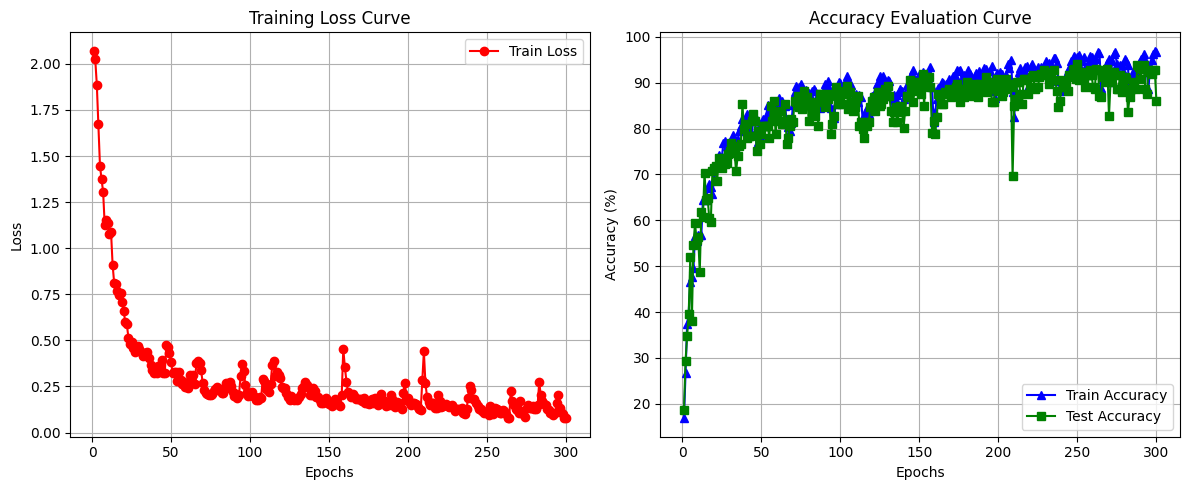

In [53]:
plt.figure(figsize=(12, 5))
epochs_range = range(1, EPOCHS + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], "r-o", label="Train Loss")
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], "b-^", label="Train Accuracy")
plt.plot(epochs_range, history["test_acc"], "g-s", label="Test Accuracy")
plt.title("Accuracy Evaluation Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()